<a href="https://colab.research.google.com/github/chandiki/Notion-SentimentAnalysis/blob/main/01_Notion_Scrapping.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Notion Google Play Review Scrapping**

**Google Play Notion: https://play.google.com/store/apps/details?id=notion.id&hl=id**

### **Instalation & Import Library**

In [1]:
!pip install google_play_scraper

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 50.2/50.2 kB 2.4 MB/s eta 0:00:00


In [2]:
from google_play_scraper import app
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import matplotlib.dates as dates
import seaborn as sns

### **Data Scrapping**

In [3]:
from google_play_scraper import app, Sort, reviews_all

notion_reviews = reviews_all(
    'notion.id', # Google Play id for notion
    sleep_milliseconds=0,
    lang='en', # review language
    sort=Sort.NEWEST,
)

In [4]:
df_result = pd.DataFrame(np.array(notion_reviews),columns=['content'])
df_result = df_result.join(pd.DataFrame(df_result.pop('content').tolist()))
df_result.to_csv(r'df_review_notion.csv', index=False)

In [5]:
df_result

,reviewId,userName,userImage,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt,appVersion
0,ab11bb0b-9e8a-4a0d-8357-b83136c1e242,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,nice,5,0,0.6.3772,2026-04-11 17:33:18,None,NaT,0.6.3772
1,1b36f732-3b30-4fba-8681-00bdb0a2d5f3,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,0.6.3772,2026-04-11 17:13:01,None,NaT,0.6.3772
2,86580816-0b44-4dcc-ac94-b9fba846e1e2,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,good,5,0,0.6.3772,2026-04-11 11:33:40,None,NaT,0.6.3772
3,6e89d61b-f230-4c61-81cf-545ced343d29,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,SOOO GOOD MUST TRY THIS APP NOTION ALWAYS SLAY...,5,0,0.6.3743,2026-04-11 06:07:33,None,NaT,0.6.3743
4,32c7d780-12bf-4fc1-a899-655114b84af6,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"It's good, but it needs features that the full...",3,0,0.6.3756,2026-04-11 05:01:43,None,NaT,0.6.3756
...,...,...,...,...,...,...,...,...,...,...,...
22982,01fbf110-9b5b-440d-94a5-a39d74f3ad47,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Notion is not only the best organizing, note ...",5,7,0.3.3,2018-06-07 08:26:06,None,NaT,0.3.3
22983,07558cfb-7ae0-4c1a-9a41-36d8070d6084,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Give me an API!,5,2,0.3.3,2018-05-18 19:18:47,None,NaT,0.3.3
22984,e9b5bead-1eda-474b-8920-2cb6cdb52fa9,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,Ignore anything other than 5-star- it's silly ...,5,10,0.3.3,2018-05-18 07:57:14,None,NaT,0.3.3
22985,89370fdf-af49-4ab0-8392-8e16cab16287,A Google user,https://play-lh.googleusercontent.com/EGemoI2N...,"Superb web app, now made easier to use. Hard t...",5,8,0.3.3,2018-04-24 14:15:34,None,NaT,0.3.3


In [6]:
df_result.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 22987 entries, 0 to 22986
Data columns (total 11 columns):
 #   Column                Non-Null Count  Dtype         
---  ------                --------------  -----         
 0   reviewId              22987 non-null  object        
 1   userName              22987 non-null  object        
 2   userImage             22987 non-null  object        
 3   content               22987 non-null  object        
 4   score                 22987 non-null  int64         
 5   thumbsUpCount         22987 non-null  int64         
 6   reviewCreatedVersion  20144 non-null  object        
 7   at                    22987 non-null  datetime64[ns]
 8   replyContent          161 non-null    object        
 9   repliedAt             161 non-null    datetime64[ns]
 10  appVersion            20144 non-null  object        
dtypes: datetime64[ns](2), int64(2), object(7)
memory usage: 1.9+ MB


In [7]:
# Filtered Columns
df_analysis = df_result.loc[:,["content","score","thumbsUpCount", "reviewCreatedVersion", "at", "replyContent", "repliedAt"]]
df_analysis


,content,score,thumbsUpCount,reviewCreatedVersion,at,replyContent,repliedAt
0,nice,5,0,0.6.3772,2026-04-11 17:33:18,None,NaT
1,good,5,0,0.6.3772,2026-04-11 17:13:01,None,NaT
2,good,5,0,0.6.3772,2026-04-11 11:33:40,None,NaT
3,SOOO GOOD MUST TRY THIS APP NOTION ALWAYS SLAY...,5,0,0.6.3743,2026-04-11 06:07:33,None,NaT
4,"It's good, but it needs features that the full...",3,0,0.6.3756,2026-04-11 05:01:43,None,NaT
...,...,...,...,...,...,...,...
22982,"Notion is not only the best organizing, note ...",5,7,0.3.3,2018-06-07 08:26:06,None,NaT
22983,Give me an API!,5,2,0.3.3,2018-05-18 19:18:47,None,NaT
22984,Ignore anything other than 5-star- it's silly ...,5,10,0.3.3,2018-05-18 07:57:14,None,NaT
22985,"Superb web app, now made easier to use. Hard t...",5,8,0.3.3,2018-04-24 14:15:34,None,NaT


In [8]:
# Distribution of reviews score
df_result['score'].value_counts()

,count
score,
5,11744
1,3654
4,3105
3,2608
2,1876


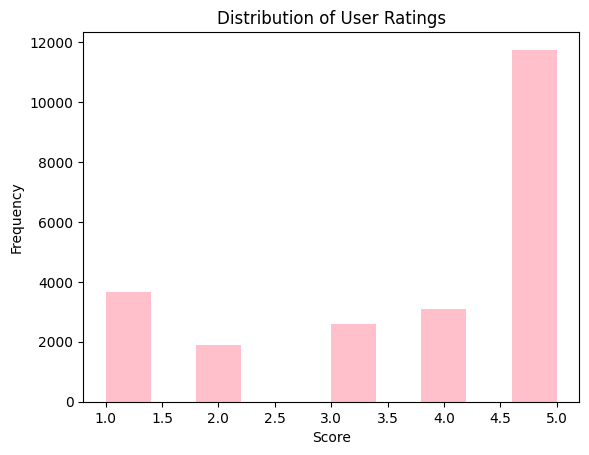

In [13]:
# Visualization
plt.hist(df_result['score'], color='#FFC0CB')
plt.xlabel('Score')
plt.ylabel('Frequency')
plt.title('Distribution of User Ratings')
plt.show()